In [3]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [4]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimiseV2') # path to parent of output_root in set_parameters
study_prefix = 'geomCombos-study1' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd'] # individual study identifier (end of dir name of output_root in set_parameters)

In [ ]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)

params = []
p_hs = ['3', '6', '9', '12']
for suffix, p_h in zip(suffixes, p_hs):
    p = get_params3d(root_dir, study_prefix, suffix)
    p['p_h'] = [p_h] * len(p)
    params.append(p)
pd.concat((params)).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [13]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [14]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

2574


Highest element count:
	14819R - 1274980


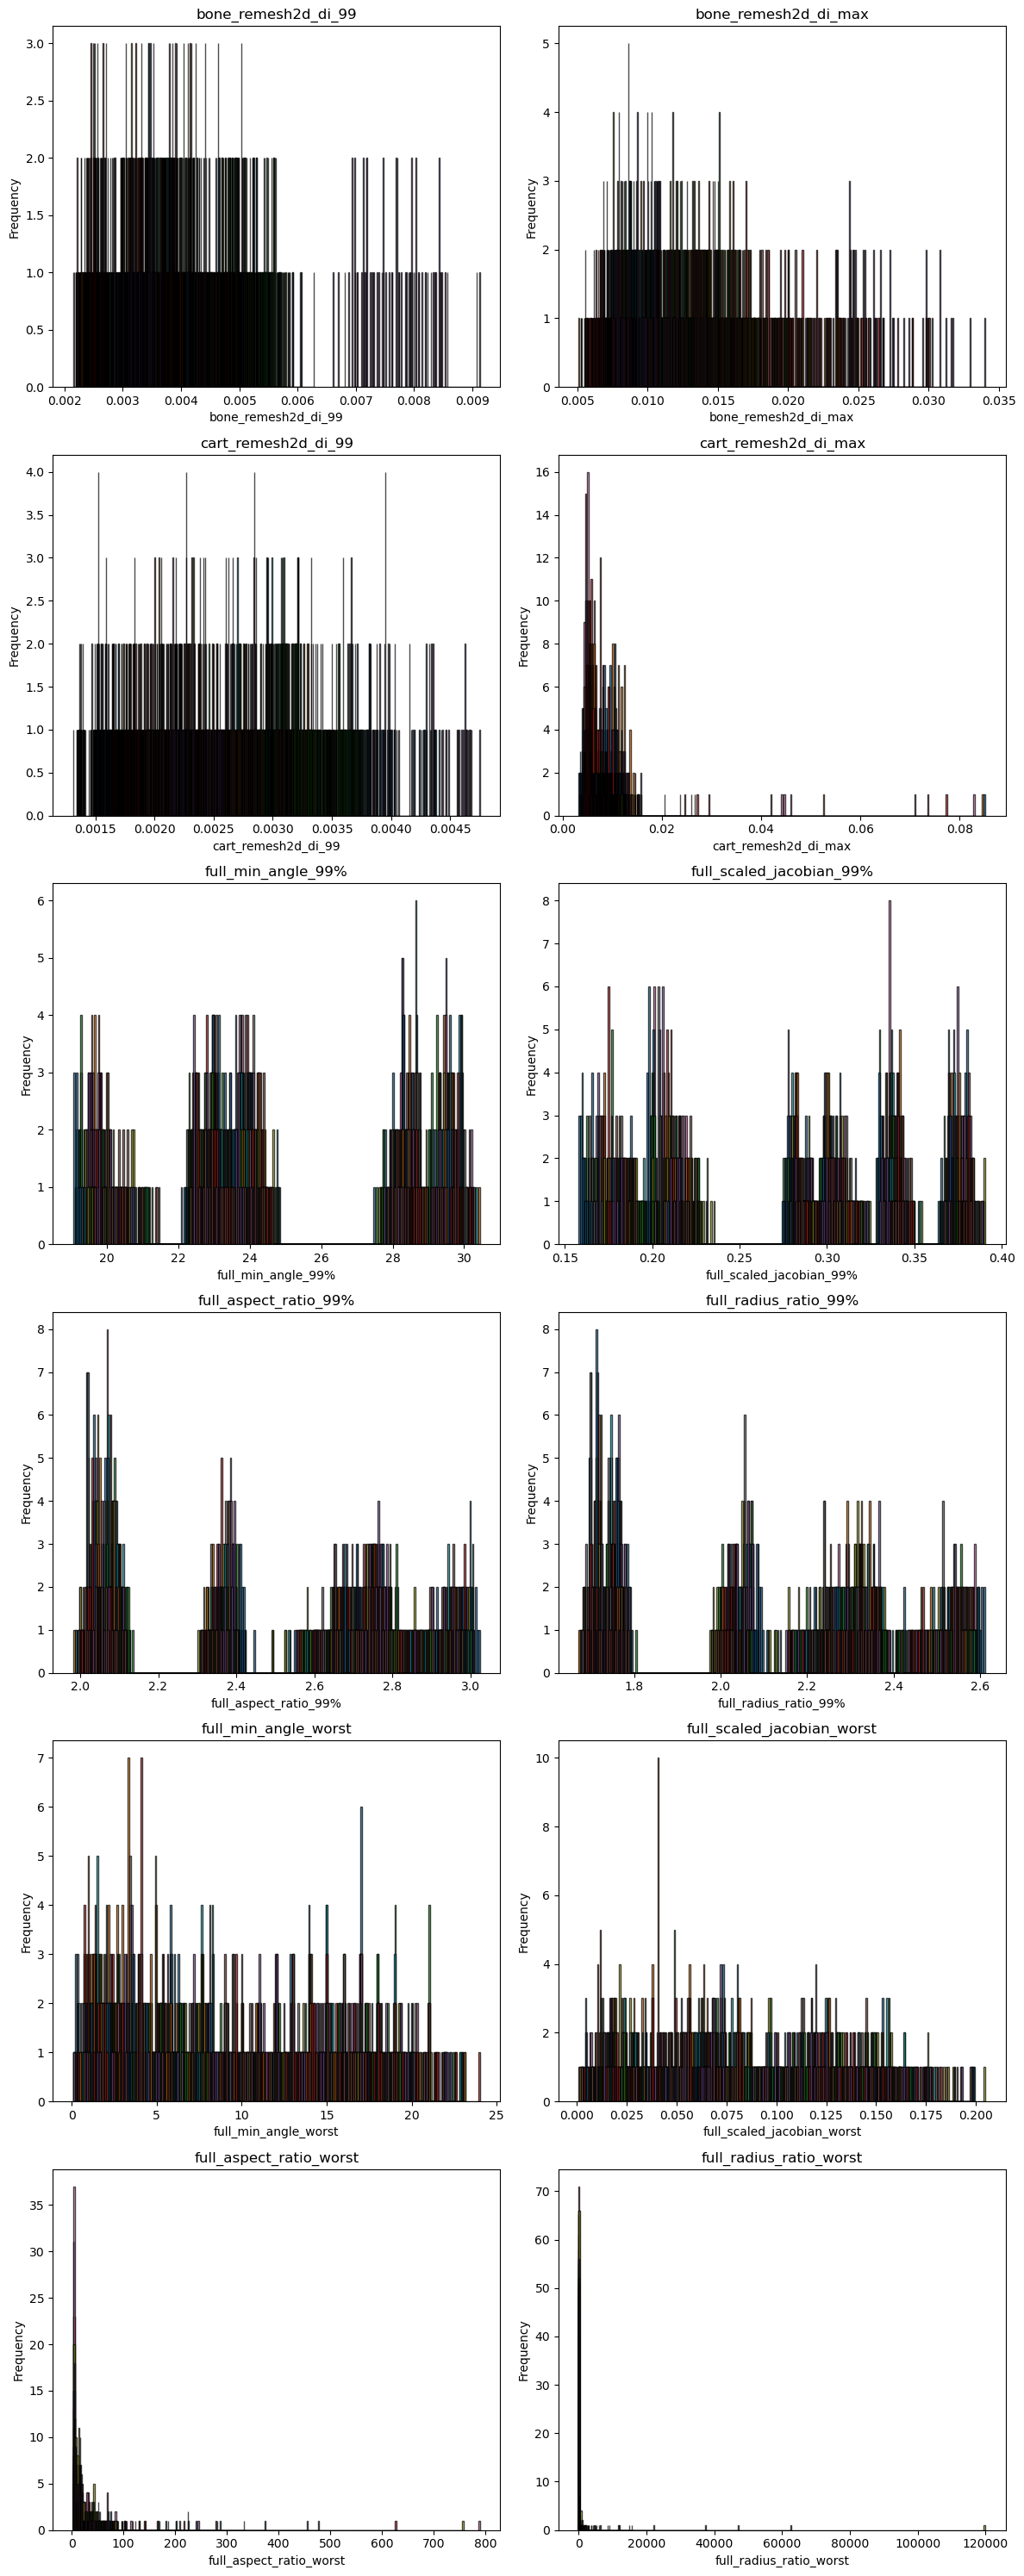

In [15]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [16]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

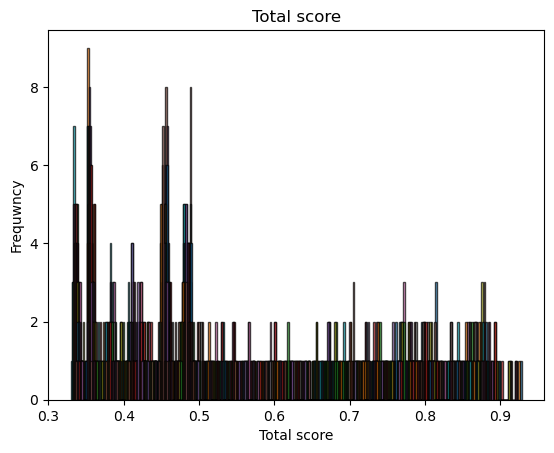

In [21]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [108]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.optimisation.odt,p_h,mean_rank,median_rank,best_rank,n_runs
71,0.30,6,True,12,10.444444,2.5,1.0,36
70,0.30,6,True,9,13.257143,10.0,1.0,35
46,0.25,6,True,9,15.600000,13.0,1.0,35
23,0.20,6,True,12,16.111111,14.5,1.0,36
47,0.25,6,True,12,16.777778,12.0,1.0,36
69,0.30,6,True,6,16.944444,17.0,1.0,36
42,0.25,6,False,9,19.457143,15.0,1.0,35
62,0.30,4,True,9,19.685714,17.0,4.0,35
43,0.25,6,False,12,19.833333,15.5,3.0,36
22,0.20,6,True,9,20.771429,23.0,1.0,35


#### Best overall params result per subject

In [145]:
group_best_params = df_grouped_rank.iloc[[4]]
print(group_best_params)
group_best_id = df_param.merge(group_best_params).run_id[0]
qual[qual['run_id']==group_best_id]

    cgal_params.sizing_field.taper_size  cgal_params.sizing_field.d0  \
47                                 0.25                            6   

    cgal_params.optimisation.odt  p_h  mean_rank  median_rank  best_rank  \
47                          True   12  16.777778         12.0        1.0   

    n_runs  
47      36  


,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,full_n_cells
1928,14548R,tpm,0-0-10-0d,29.060820,0.374632,2.063082,1.736370,3.703947,0.054172,15.052962,37.507756,161397
1946,14613R,tpm,0-0-10-0d,29.514348,0.371164,2.040238,1.717874,10.714608,0.132850,5.087425,4.838886,560022
1964,14685R,tpm,0-0-10-0d,29.651283,0.377676,2.034691,1.709689,14.046791,0.161957,4.217306,3.641408,296141
1982,14726R,tpm,0-0-10-0d,29.793953,0.380549,2.020382,1.698669,16.636312,0.141658,3.701568,5.200372,606395
2000,14727R,tpm,0-0-10-0d,29.677702,0.376043,2.029986,1.706700,0.129075,0.002138,478.394901,47214.482520,502934
2018,14818R,tpm,0-0-10-0d,29.502120,0.376804,2.041711,1.717688,17.010035,0.121411,4.104850,4.103322,174744
2036,14819R,tpm,0-0-10-0d,30.021998,0.379265,2.007557,1.687962,17.222060,0.134757,3.622170,3.652690,1221155
2054,14827L,tpm,0-0-10-0d,29.720913,0.382822,2.021801,1.699008,19.494427,0.155850,3.946329,3.283220,250157
2072,14873R,tpm,0-0-10-0d,29.474124,0.381543,2.042483,1.714520,1.834346,0.030476,34.776057,261.223415,256202
2090,14874R,tpm,0-0-10-0d,29.847248,0.376836,2.021906,1.700964,8.373346,0.129551,6.963183,7.268891,1125824


In [141]:
group_best_per_sub = df_score_param[df_score_param['run_id']==group_best_id]
group_best_per_sub

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.optimisation.odt,p_h
1,50007L,tpm,0-0-10-0c,0.993925,0.933219,1.0,1.0,1.000000,0.485906,1.000000e+00,1.000000e+00,0.926631,1.0,0.25,6,True,9
19,50000R,tpm,0-0-10-0c,0.997947,0.917260,1.0,1.0,1.000000,0.239747,1.000000e+00,1.000000e+00,0.894369,1.0,0.25,6,True,9
20,50018L,tpm,0-0-10-0c,1.000000,0.945836,1.0,1.0,1.000000,0.208514,1.000000e+00,1.000000e+00,0.894294,1.0,0.25,6,True,9
32,50020R,tpm,0-0-10-0c,0.992427,0.919044,1.0,1.0,1.000000,0.180163,1.000000e+00,1.000000e+00,0.886454,2.0,0.25,6,True,9
38,15441R,tpm,0-0-10-0c,0.992433,0.882892,1.0,1.0,1.000000,0.191544,1.000000e+00,1.000000e+00,0.883359,1.0,0.25,6,True,9
58,50053R,tpm,0-0-10-0c,0.991172,0.920029,1.0,1.0,1.000000,0.107506,1.000000e+00,1.000000e+00,0.877338,5.0,0.25,6,True,9
67,14818R,tpm,0-0-10-0c,0.990523,0.904690,1.0,1.0,1.000000,0.110496,1.000000e+00,1.000000e+00,0.875714,6.0,0.25,6,True,9
73,14819R,tpm,0-0-10-0c,0.998381,0.889833,1.0,1.0,1.000000,0.099452,1.000000e+00,1.000000e+00,0.873458,3.0,0.25,6,True,9
76,50001R,tpm,0-0-10-0c,0.992108,0.893027,1.0,1.0,1.000000,0.096271,1.000000e+00,1.000000e+00,0.872676,2.0,0.25,6,True,9
89,50049R,tpm,0-0-10-0c,0.982095,0.866971,1.0,1.0,1.000000,0.107968,1.000000e+00,1.000000e+00,0.869629,3.0,0.25,6,True,9


In [142]:
bad_subs = group_best_per_sub[group_best_per_sub['total']<0.85][['sub']]
bad_subs['sub'].values

<StringArray>
['15006R', '14726R', '50021R', '50045R', '50017L', '14827L', '50034R',
 '14613R', '50019R', '14685R', '15737R', '14873R', '14727R', '14874R',
 '50014R', '15283R', '50006R', '50024R', '14548R', '22306R', '15294R',
 '50027L']
Length: 22, dtype: str

In [126]:

group_tw_params = df_grouped_rank.iloc[[8]]

group_tw_id = df_param.merge(group_tw_params).run_id[0]
#bad_subs.merge(qual[qual['run_id']==group_tw_id])
bad_subs.merge(df_score_param[df_score_param['run_id']==group_tw_id]).sort_values('total', ascending=False)['total']

0     0.815649
3     0.809201
8     0.801896
9     0.787344
13    0.778806
1     0.775349
4     0.753269
14    0.711077
10    0.676556
12    0.505289
2     0.458155
11    0.446200
6     0.445817
5     0.437551
7     0.417780
Name: total, dtype: float64

#### Best per subject

In [64]:
df_score_qual[['sub', 'bone', 'run_id', 'total']+[x for x in df_score_qual.columns if '_y' in x]].groupby('sub').first()

,bone,run_id,total,full_min_angle_worst_y,full_min_angle_99%_y,full_radius_ratio_worst_y,full_radius_ratio_99%_y,full_aspect_ratio_worst_y,full_aspect_ratio_99%_y,full_scaled_jacobian_worst_y,full_scaled_jacobian_99%_y
sub,,,,,,,,,,,
14548R,tpm,0-0-16-0d,0.921523,21.044927,29.708417,2.862936,1.705226,3.096836,2.024148,0.199428,0.378083
14613R,tpm,0-0-16-0c,0.856662,17.653079,29.645053,4.248620,1.713351,3.730551,2.032568,0.153238,0.373299
14685R,tpm,0-0-4-0d,0.894607,20.816159,29.864045,3.112172,1.695547,3.074228,2.015877,0.174783,0.385347
14726R,tpm,0-0-10-0c,0.835998,14.004496,29.717397,3.818632,1.702404,4.278022,2.026312,0.117248,0.378840
14727R,tpm,0-0-8-0c,0.834745,18.192973,28.649505,3.168175,1.742987,3.799853,2.064617,0.102421,0.339241
14818R,tpm,0-0-16-0b,0.913048,21.799369,29.894525,2.712657,1.698189,3.062228,2.013387,0.192806,0.380992
14819R,tpm,0-0-4-0d,0.881618,20.363663,30.234755,3.000538,1.681010,3.250494,1.997472,0.158163,0.382084
14827L,tpm,0-0-16-0d,0.880473,23.001543,30.299836,2.614220,1.677581,3.101023,1.992618,0.144116,0.390054
14873R,tpm,0-0-16-0c,0.915042,21.058255,30.178193,3.538740,1.681831,3.368603,1.998003,0.189764,0.390508


In [65]:
df_score_param.groupby('sub').first()

,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.optimisation.odt,p_h
sub,,,,,,,,,,,,,,,,
14548R,tpm,0-0-16-0d,0.990281,0.890414,1.0,1.0,1.000000,0.491493,1.000000,1.00000,0.921523,1.0,0.30,6,True,12
14613R,tpm,0-0-16-0c,0.988168,0.866496,1.0,1.0,1.000000,0.122945,1.000000,0.87569,0.856662,1.0,0.30,6,True,9
14685R,tpm,0-0-4-0d,0.995468,0.926733,1.0,1.0,1.000000,0.234652,1.000000,1.00000,0.894607,1.0,0.20,6,True,12
14726R,tpm,0-0-10-0c,0.990580,0.894200,1.0,1.0,0.900450,0.041764,0.860989,1.00000,0.835998,1.0,0.25,6,True,9
14727R,tpm,0-0-8-0c,0.954984,0.696205,1.0,1.0,1.000000,0.026769,1.000000,1.00000,0.834745,1.0,0.25,4,True,9
14818R,tpm,0-0-16-0b,0.996484,0.904958,1.0,1.0,1.000000,0.402944,1.000000,1.00000,0.913048,1.0,0.30,6,True,6
14819R,tpm,0-0-4-0d,1.000000,0.910420,1.0,1.0,1.000000,0.142520,1.000000,1.00000,0.881618,1.0,0.20,6,True,12
14827L,tpm,0-0-16-0d,1.000000,0.950270,1.0,1.0,1.000000,0.093511,1.000000,1.00000,0.880473,1.0,0.30,6,True,12
14873R,tpm,0-0-16-0c,1.000000,0.952540,1.0,1.0,1.000000,0.367793,1.000000,1.00000,0.915042,1.0,0.30,6,True,9


In [148]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/optimiseV2/geomCombos-study1d/meshes/22306R/tpm-mc1/3Dmesh/mesh-0-0-4.vtu'
pv.read(path).plot()
# 10c, 4d, 10d


Widget(value='<iframe src="http://localhost:50610/index.html?ui=P_0x34fbc7dd0_3&reconnect=auto" class="pyvista…

# Thoughts
 - Need to limit taper size to 0.25 to prevent significant holes
 - 8.5 looks good for this
---
#### But all this probably depends on n_tets
 - Use above params and do n_tets simulations with 50000R (cos smallest contact so high def and pressure)
 - Need good meshes for 50000R for n_tets = [1, 2, 3]